In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/house-prices-tp.csv')



In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [ ]:
missing_data_proportion = df.isnull().sum() / len(df)
missing_data_df = pd.DataFrame({'Column': missing_data_proportion.index, 'Missing Proportion': missing_data_proportion.values})
print(missing_data_df)

     Column  Missing Proportion
0      CRIM            0.041367
1        ZN            0.039568
2     INDUS            0.026978
3      CHAS            0.041367
4       NOX            0.043165
5        RM            0.037770
6       AGE            0.043165
7       DIS            0.026978
8       RAD            0.050360
9       TAX            0.032374
10  PTRATIO            0.050360
11        B            0.039568
12    LSTAT            0.039568
13     MEDV            0.037770


In [ ]:
# Eliminar filas donde 'MEDV' es nulo
df.dropna(subset=['MEDV'], inplace=True)
print(f"Dimensiones del DataFrame después de eliminar nulos en MEDV: {df.shape}")

Dimensiones del DataFrame después de eliminar nulos en MEDV: (535, 14)


In [ ]:
missing_data_proportion = df.isnull().sum() / len(df)
missing_data_df = pd.DataFrame({'Column': missing_data_proportion.index, 'Missing Proportion': missing_data_proportion.values})
print(missing_data_df)

     Column  Missing Proportion
0      CRIM            0.020561
1        ZN            0.020561
2     INDUS            0.007477
3      CHAS            0.016822
4       NOX            0.016822
5        RM            0.013084
6       AGE            0.020561
7       DIS            0.009346
8       RAD            0.022430
9       TAX            0.016822
10  PTRATIO            0.016822
11        B            0.016822
12    LSTAT            0.016822
13     MEDV            0.000000


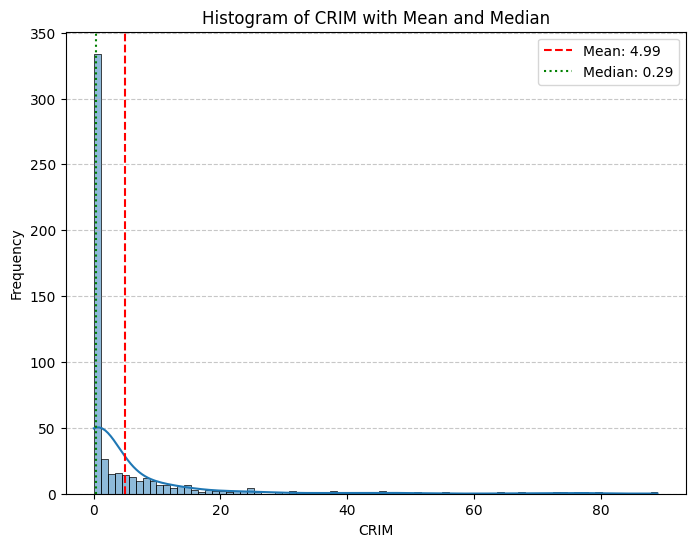

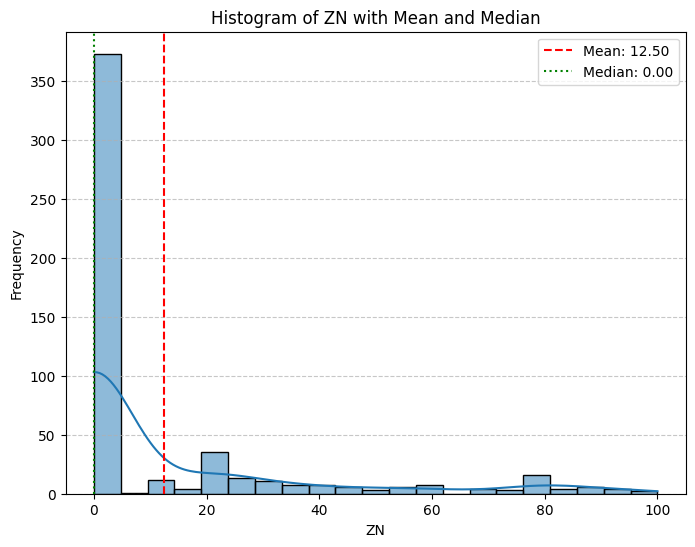

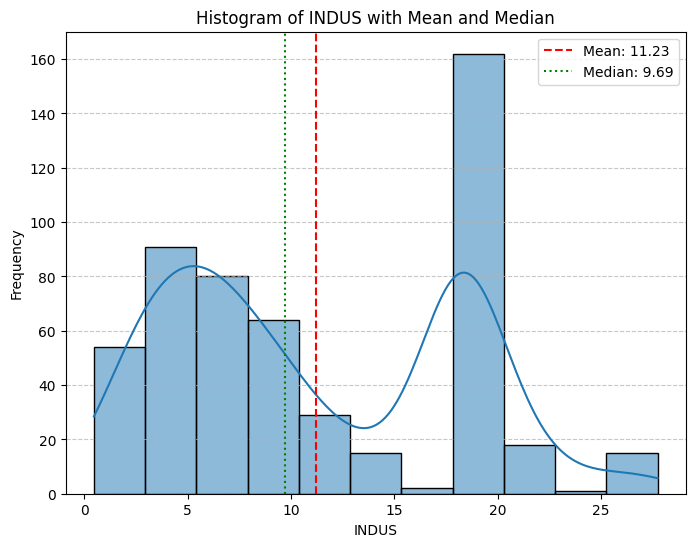

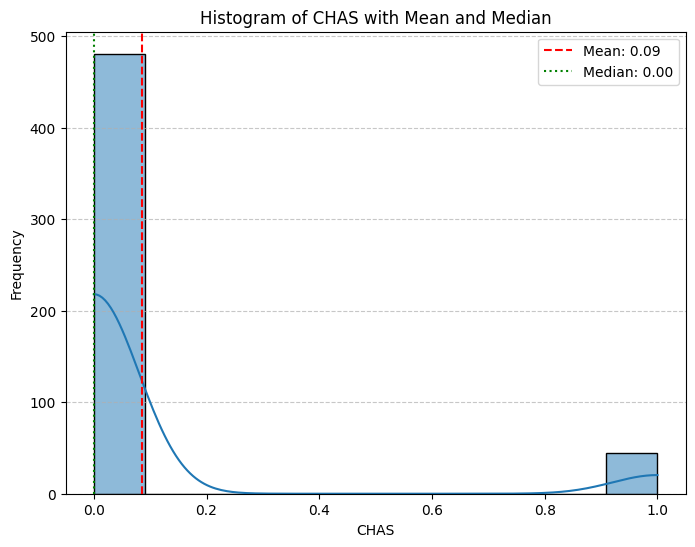

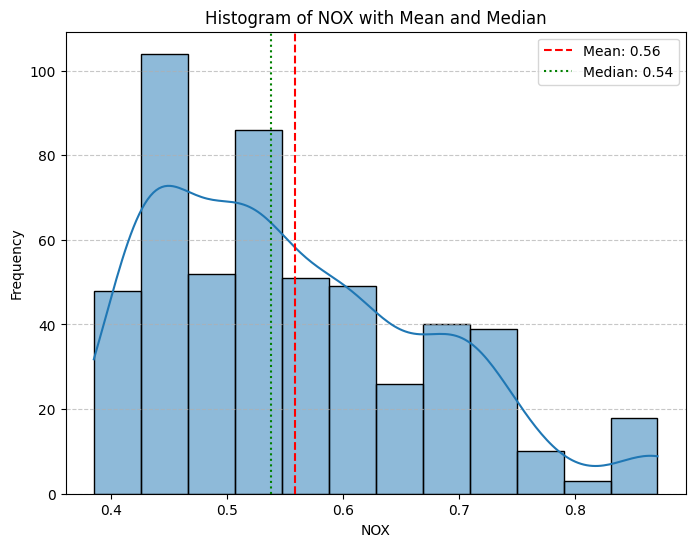

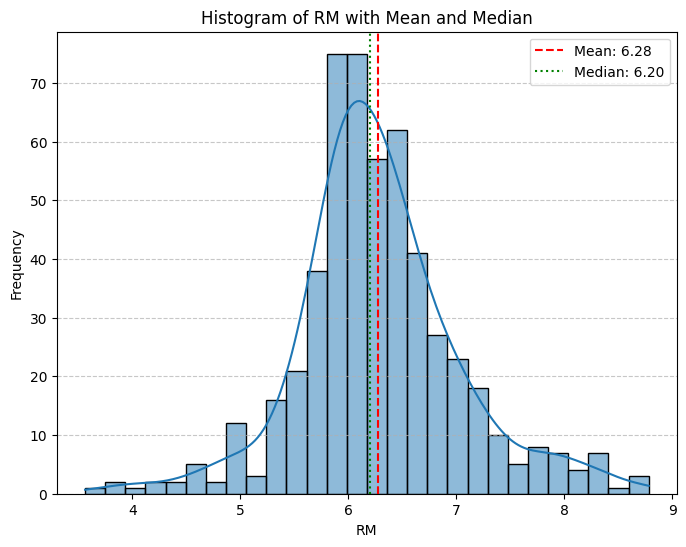

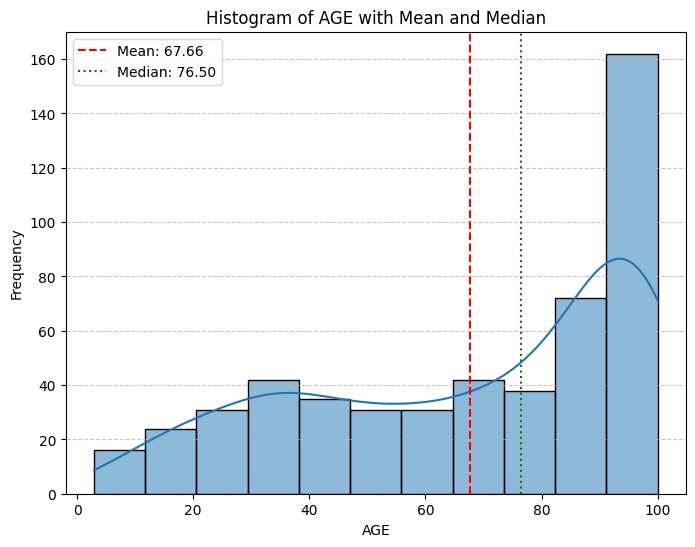

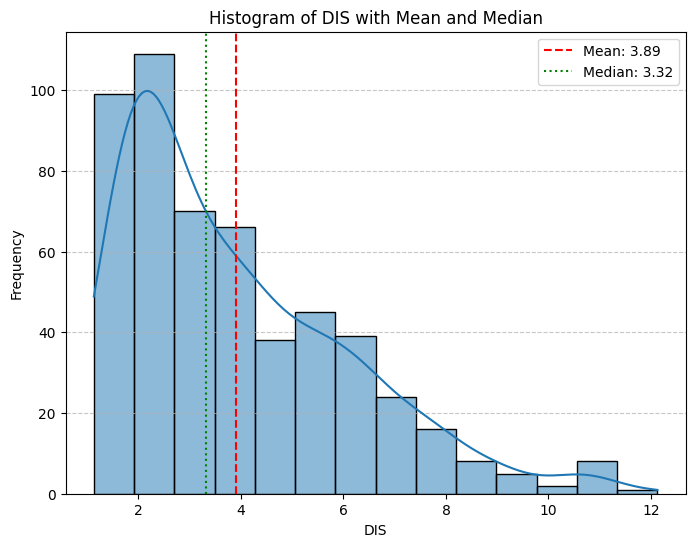

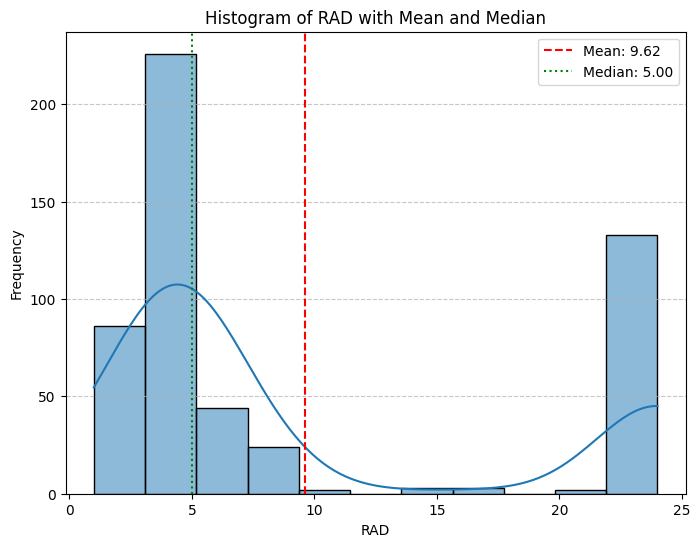

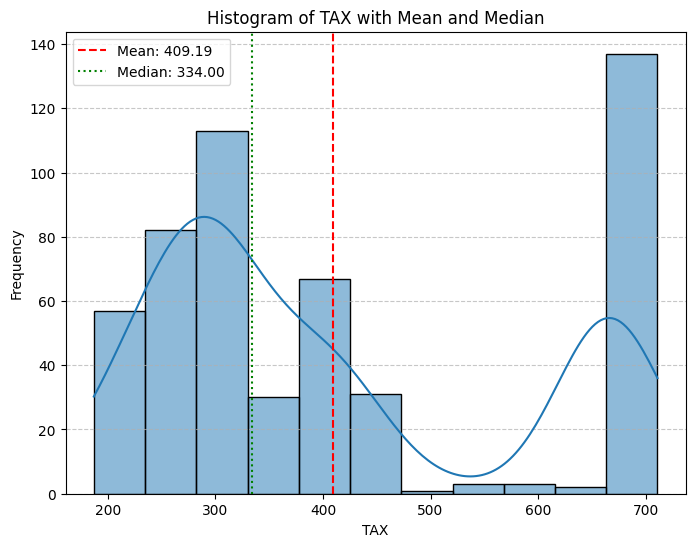

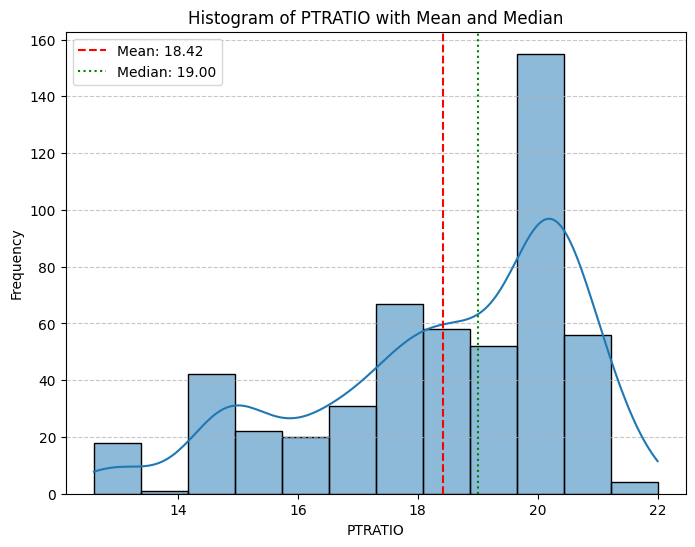

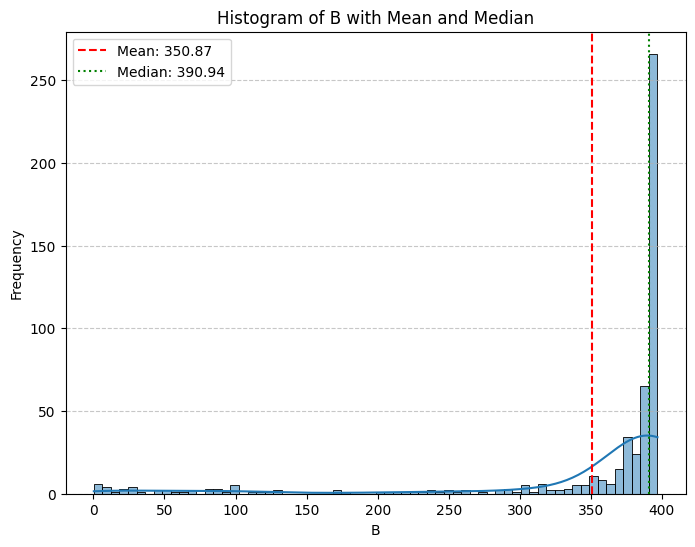

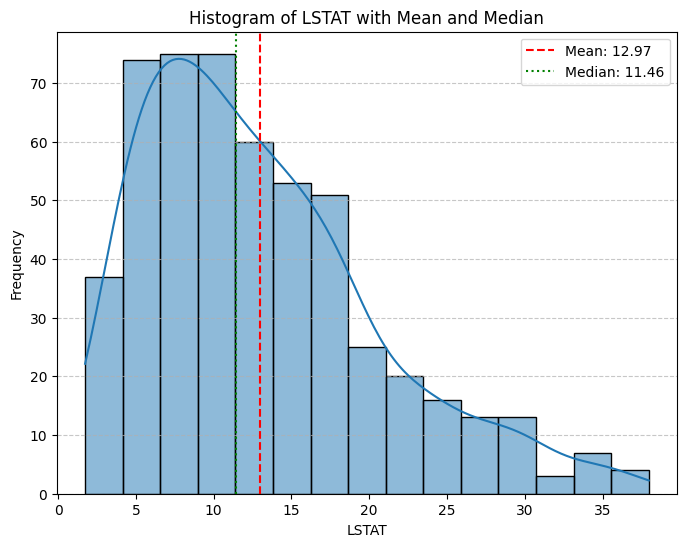

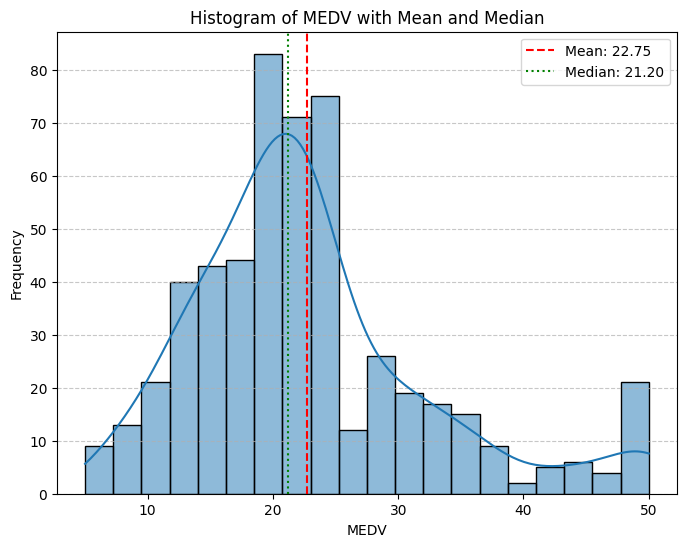

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all column names from the DataFrame
columns = df.columns.tolist()

# Generate a histogram for each column
for col in columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col].dropna(), kde=True) # kde=True adds a Kernel Density Estimate; dropna to handle missing values

    # Calculate mean and median, dropping NaN values first
    mean_val = df[col].mean()
    median_val = df[col].median()

    # Add vertical line for the mean
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    # Add vertical line for the median
    plt.axvline(median_val, color='green', linestyle=':', label=f'Median: {median_val:.2f}')

    plt.title(f'Histogram of {col} with Mean and Median')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend() # Show the legend for mean and median lines
    plt.show()

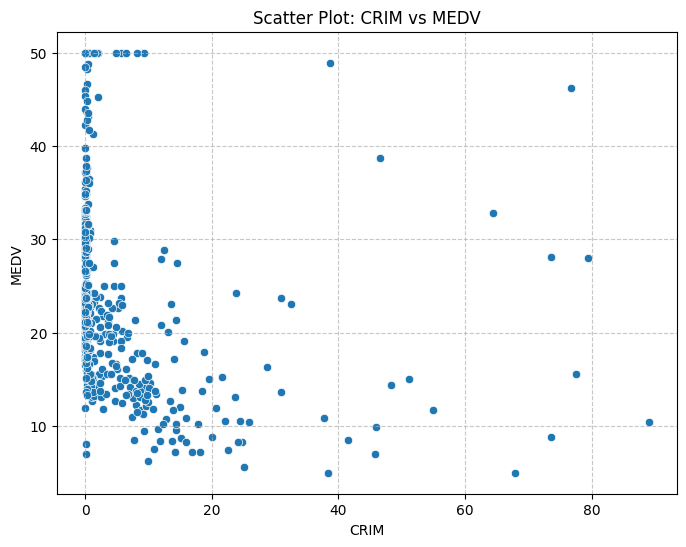

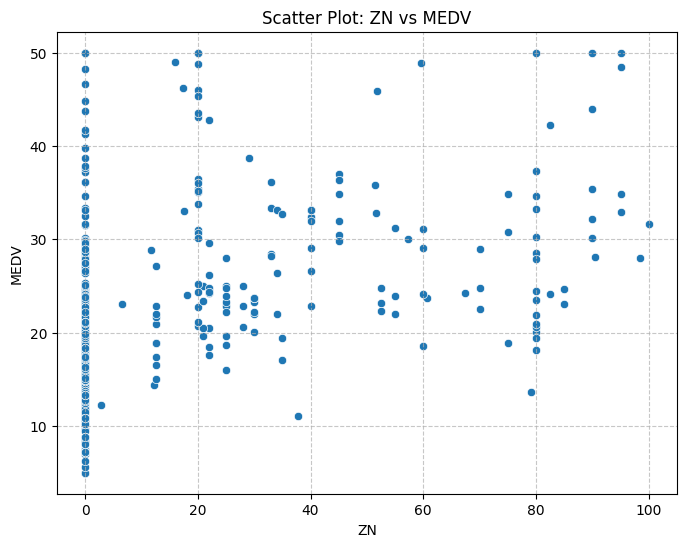

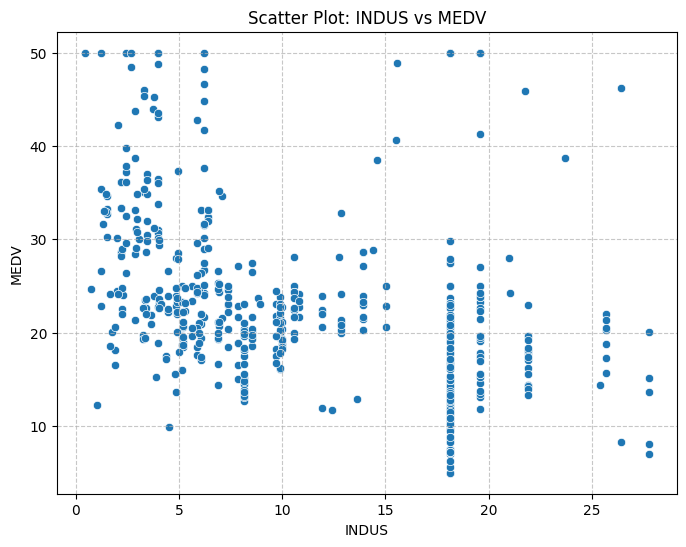

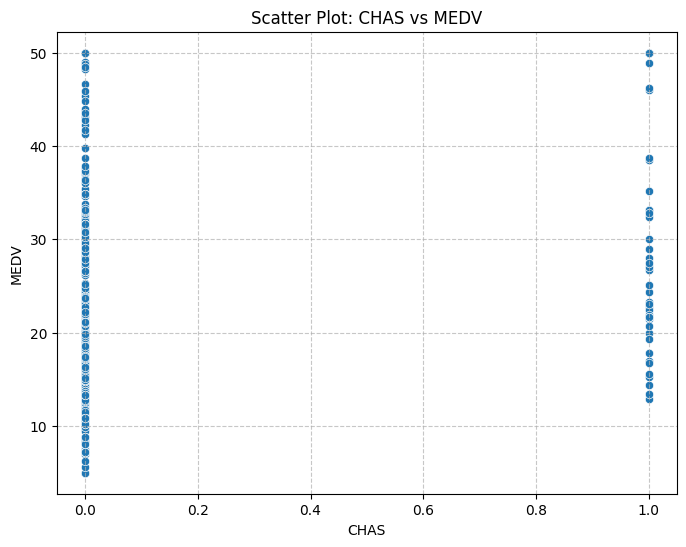

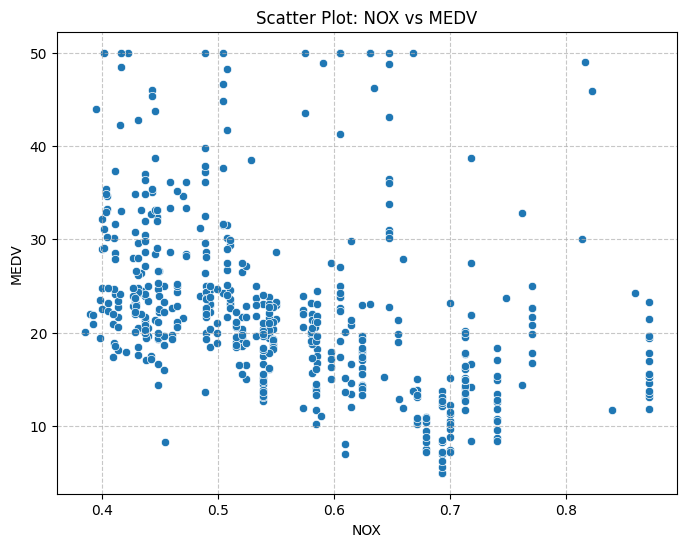

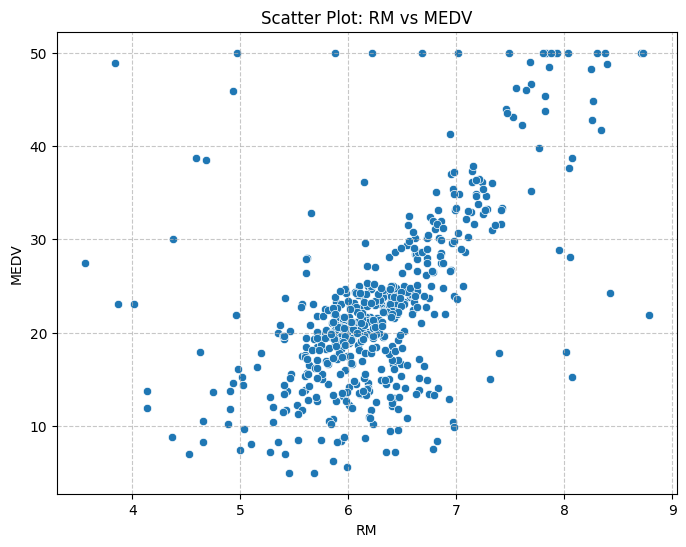

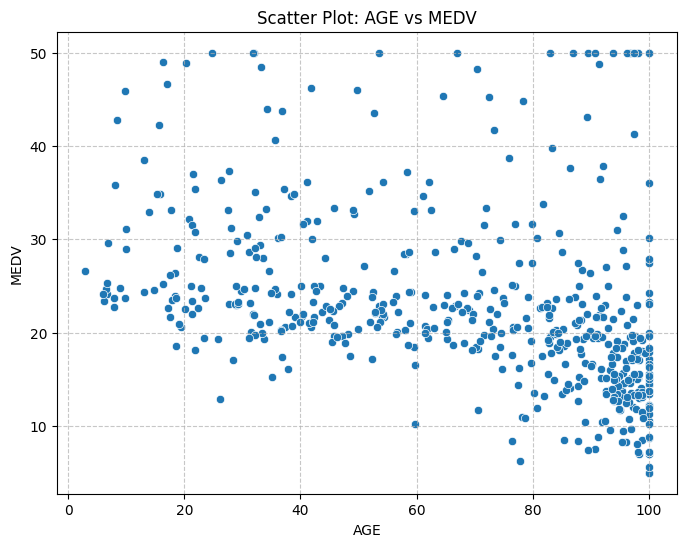

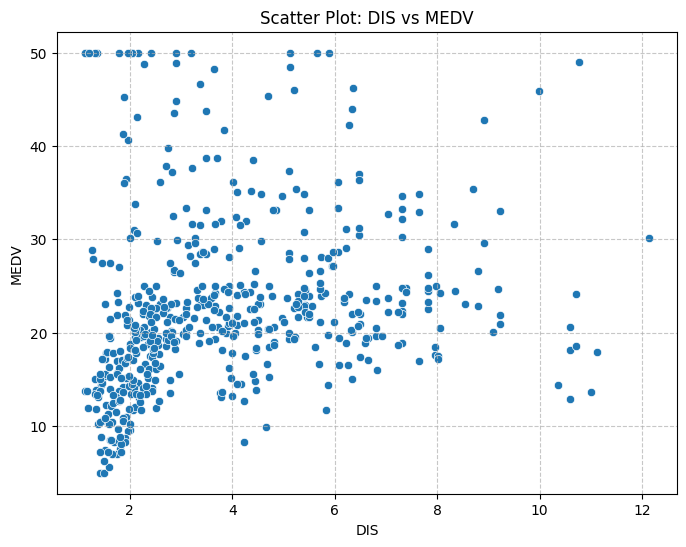

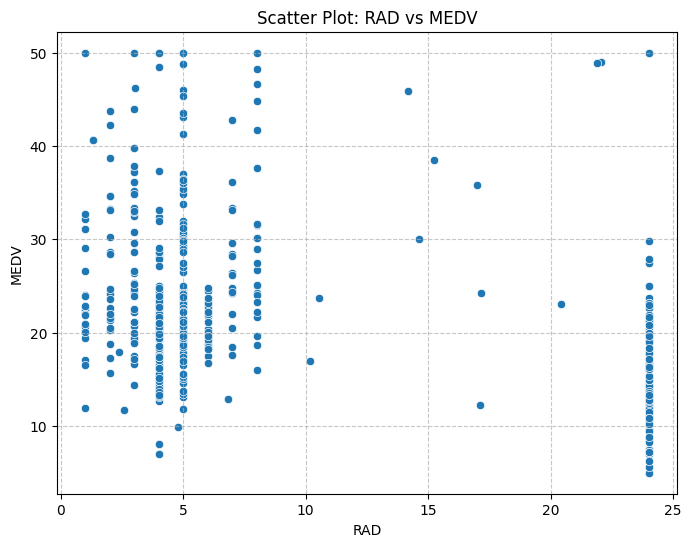

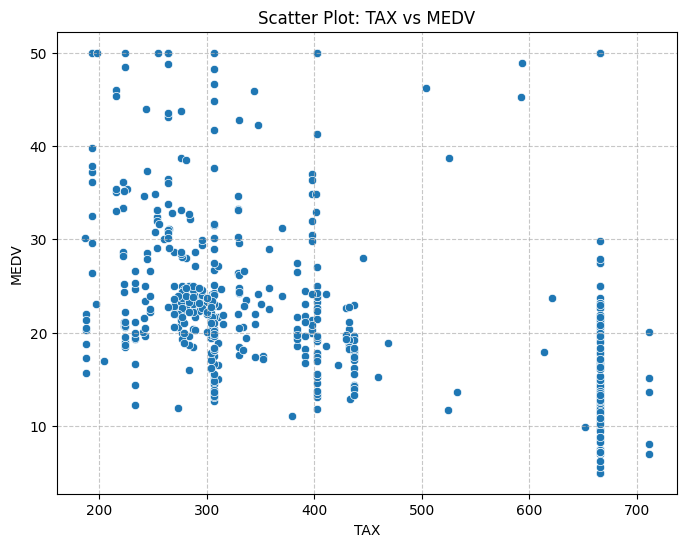

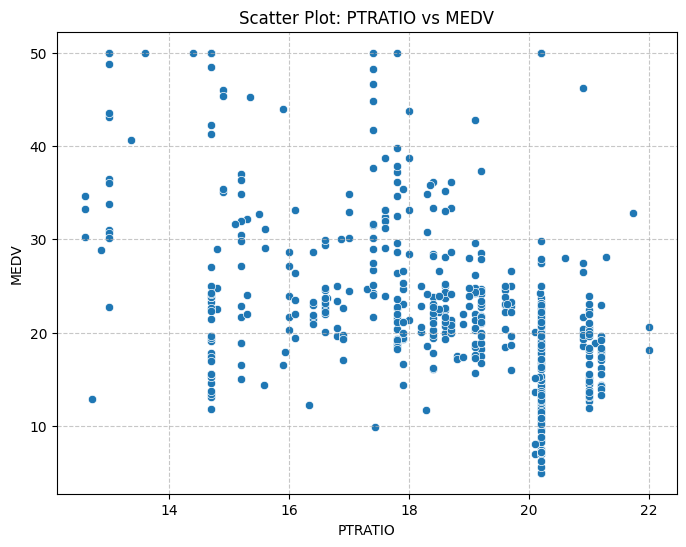

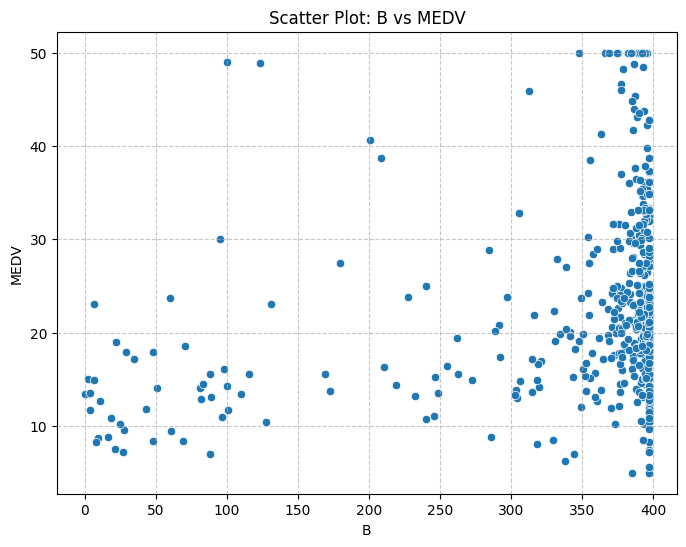

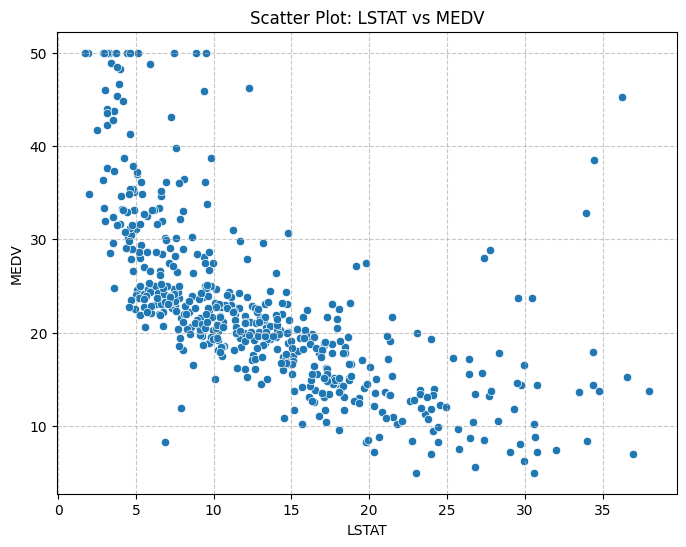

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all column names from the DataFrame
columns = df.columns.tolist()

# Remove 'MEDV' from the list of columns to plot against itself
if 'MEDV' in columns:
    columns.remove('MEDV')

# Generate a scatter plot for each column against 'MEDV'
for col in columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[col], y=df['MEDV'])
    plt.title(f'Scatter Plot: {col} vs MEDV')
    plt.xlabel(col)
    plt.ylabel('MEDV')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

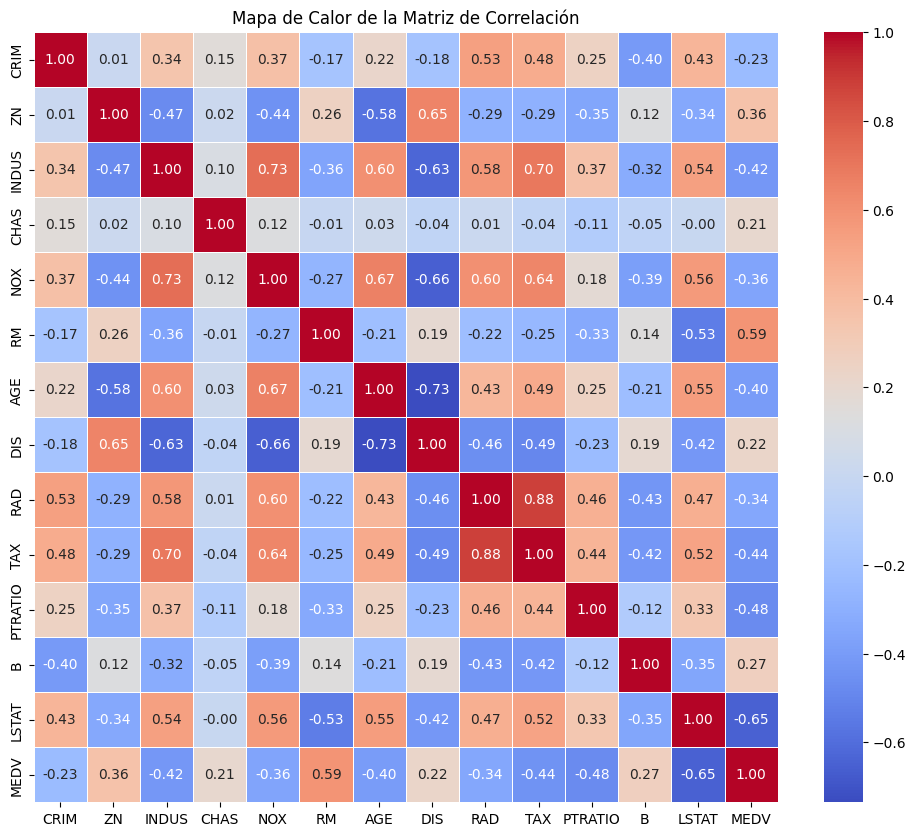

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de la Matriz de Correlación')
plt.show()

### Split Dataset

In [ ]:
# Importar la función train_test_split
from sklearn.model_selection import train_test_split
import pandas as pd # Asegurarse de que pandas esté importado

# Definir las características (X) y la variable objetivo (y)
X = df.drop('MEDV', axis=1) # Todas las columnas excepto 'MEDV' son características
y = df['MEDV'] # 'MEDV' es la variable objetivo

# Dividir los datos en conjuntos de entrenamiento y prueba
# Usamos un 80% para entrenamiento y un 20% para prueba
# random_state asegura que la división sea reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento de características (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba de características (X_test): {X_test.shape}")
print(f"Tamaño del conjunto de entrenamiento de la variable objetivo (y_train): {y_train.shape}")
print(f"Tamaño del conjunto de prueba de la variable objetivo (y_test): {y_test.shape}")
print(f"Número de NaNs en y_train: {y_train.isnull().sum()}")
print(f"Número de NaNs en y_test: {y_test.isnull().sum()}")

Tamaño del conjunto de entrenamiento de características (X_train): (428, 13)
Tamaño del conjunto de prueba de características (X_test): (107, 13)
Tamaño del conjunto de entrenamiento de la variable objetivo (y_train): (428,)
Tamaño del conjunto de prueba de la variable objetivo (y_test): (107,)
Número de NaNs en y_train: 0
Número de NaNs en y_test: 0


### Imputación de Datos Faltantes
Primero, imputaremos los valores faltantes en las características (`X_train` y `X_test`) utilizando la mediana de cada columna. Esto lo haremos solo en el conjunto de entrenamiento para evitar la fuga de información del conjunto de prueba.

In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np

# Crear un imputador con la estrategia de mediana
imputer = SimpleImputer(strategy='mean')

# Ajustar el imputador solo en el conjunto de entrenamiento (X_train)
imputer.fit(X_train)

# Transformar X_train y X_test
X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convertir los arrays resultantes de nuevo a DataFrames con los nombres de columna originales
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

print("Valores nulos en X_train después de la imputación:")
display(X_train_imputed.isnull().sum().sum())
print("Valores nulos en X_test después de la imputación:")
display(X_test_imputed.isnull().sum().sum())

Valores nulos en X_train después de la imputación:


np.int64(0)

Valores nulos en X_test después de la imputación:


np.int64(0)

### Normalización de Datos
Ahora, normalizaremos las características imputadas utilizando `StandardScaler`. Esto transformará los datos para que tengan una media de 0 y una desviación estándar de 1. Al igual que con la imputación, ajustaremos el escalador solo en el conjunto de entrenamiento.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Crear un escalador estándar
scaler = StandardScaler()

# Ajustar el escalador solo en el conjunto de entrenamiento imputado
scaler.fit(X_train_imputed)

# Transformar X_train_imputed y X_test_imputed
X_train_scaled = scaler.transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Convertir los arrays escalados de nuevo a DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Primeras 5 filas de X_train_scaled (características de entrenamiento normalizadas):")
display(X_train_scaled.head())
print("Primeras 5 filas de X_test_scaled (características de prueba normalizadas):")
display(X_test_scaled.head())

Primeras 5 filas de X_train_scaled (características de entrenamiento normalizadas):


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
290,-0.414025,-0.517254,-0.236076,-0.274921,2.062154e-01,-0.799391,-1.358745,-0.491937,-4.469527e-01,-1.490602e-01,0.362040,0.454631,0.593539
357,-0.424905,-0.517254,0.088795,-0.274921,1.047895e-01,-0.321734,0.456869,-0.625881,-1.018960e+00,-8.491087e-01,1.174063,0.491261,-0.694260
458,0.605716,-0.043015,0.447633,-0.274921,-9.383783e-16,2.224582,0.973343,-1.192401,-2.032177e-16,3.372301e-16,-2.495745,-0.646301,1.943535
438,-0.419707,0.503895,-0.897420,-0.274921,-9.094698e-01,0.243493,0.002966,1.527672,-2.181500e-01,-7.838499e-01,0.587602,0.491261,-0.846623
153,0.763686,-0.517254,0.983640,-0.274921,1.516300e+00,0.250127,0.893315,-0.855082,1.612272e+00,1.482409e+00,0.813164,-3.256999,0.653160


Primeras 5 filas de X_test_scaled (características de prueba normalizadas):


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
121,-0.417979,-0.517254,-0.399962,-0.274921,-0.343175,-0.193032,0.610498,-0.800428,-0.561354,-1.905885e-01,1.128951e+00,0.397810,0.128501
136,-0.407832,-0.517254,-0.639264,-0.274921,-0.951731,-1.158961,0.963146,0.909275,-0.790157,-1.086413e+00,-2.244216e-01,0.491261,2.343728
158,0.000000,0.137344,0.000000,-0.274921,2.156957,1.868516,-1.792514,3.145816,1.391421,3.372301e-16,1.602715e-15,-2.521997,0.000000
250,-0.417590,-0.517254,-0.105548,3.706693,-0.605192,-0.276622,-0.300800,0.165283,-0.675755,-8.253782e-01,9.136529e-02,0.333177,0.204020
87,-0.410458,-0.517254,-0.189666,-0.274921,-0.114967,-0.239471,0.966638,-0.606264,-0.446953,9.417694e-02,-2.695340e-01,0.491261,0.525970


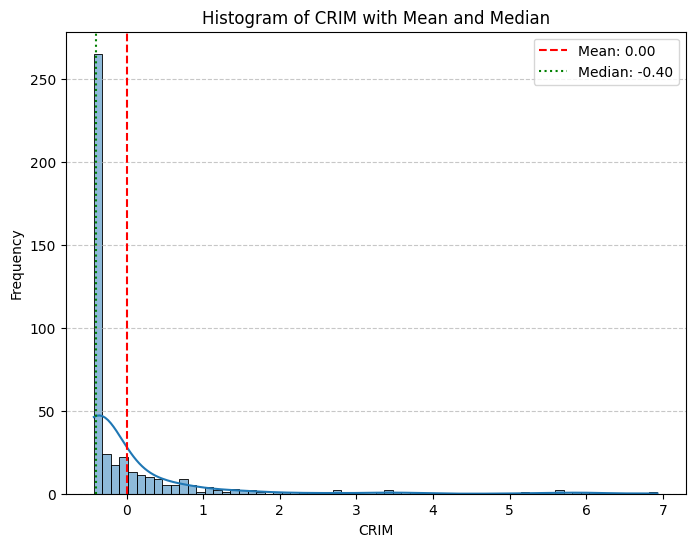

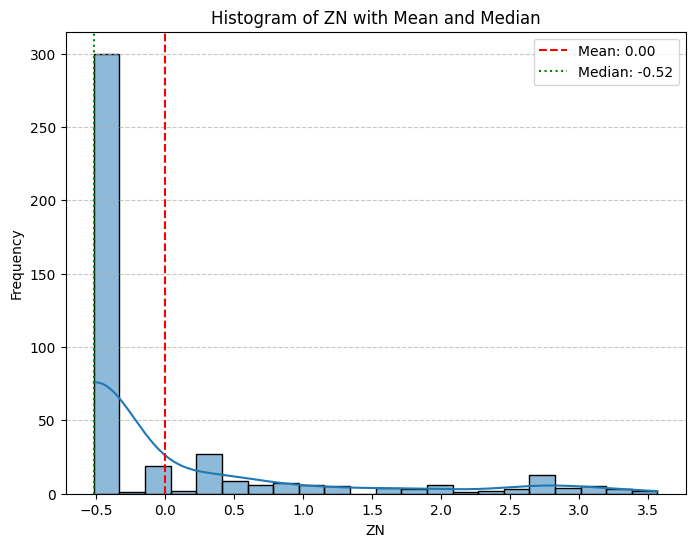

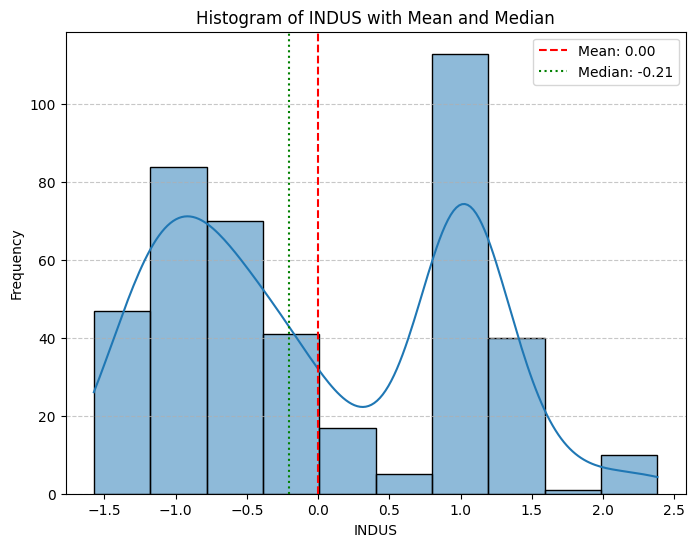

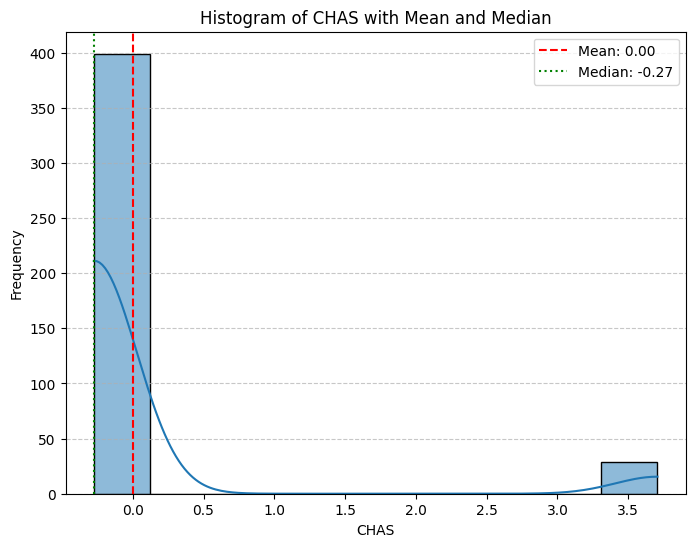

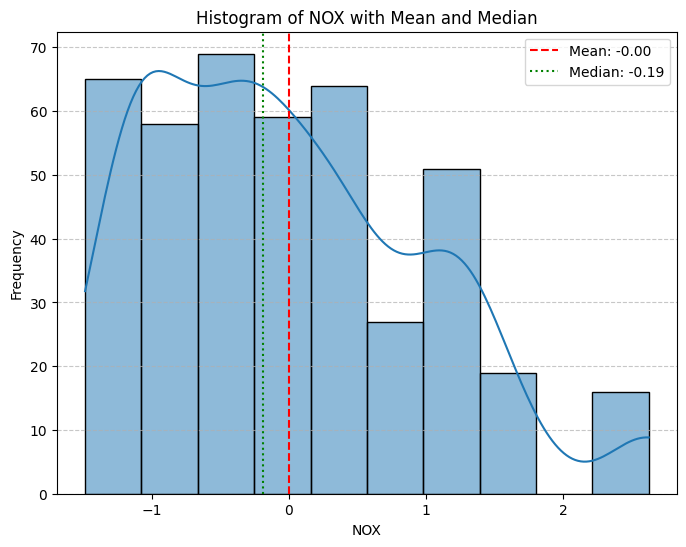

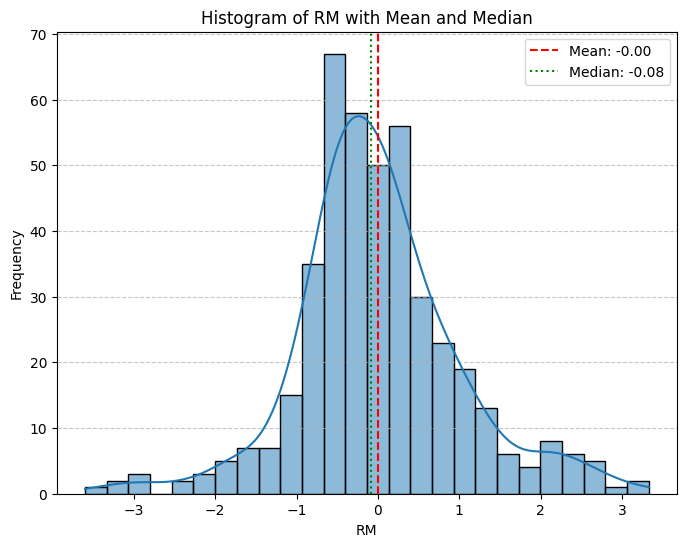

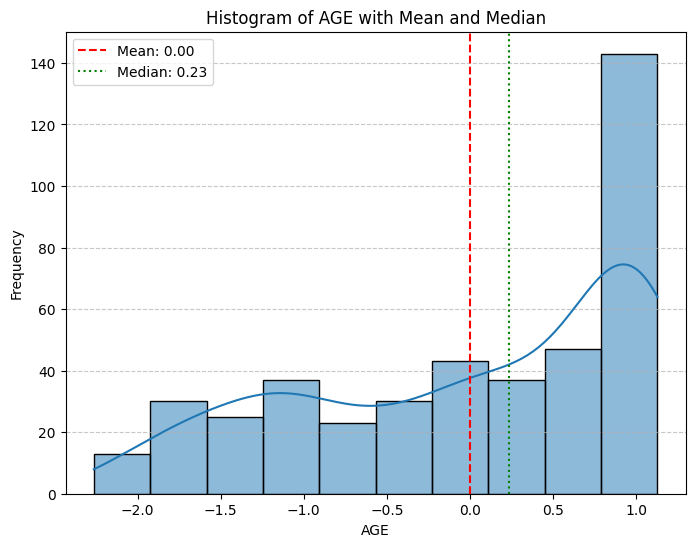

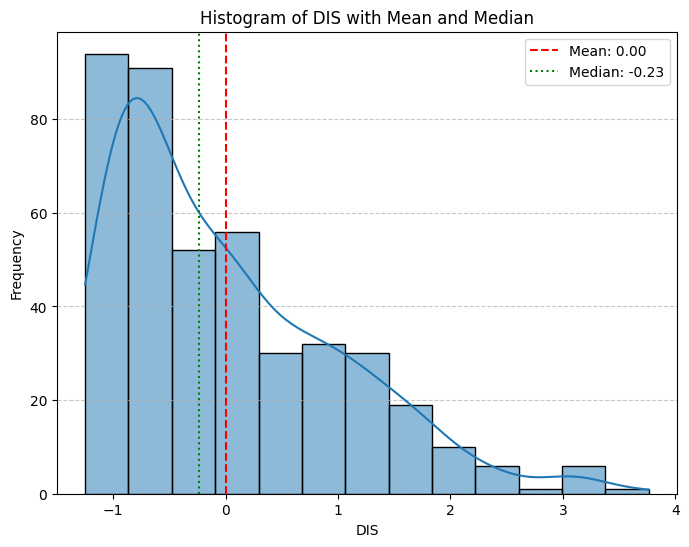

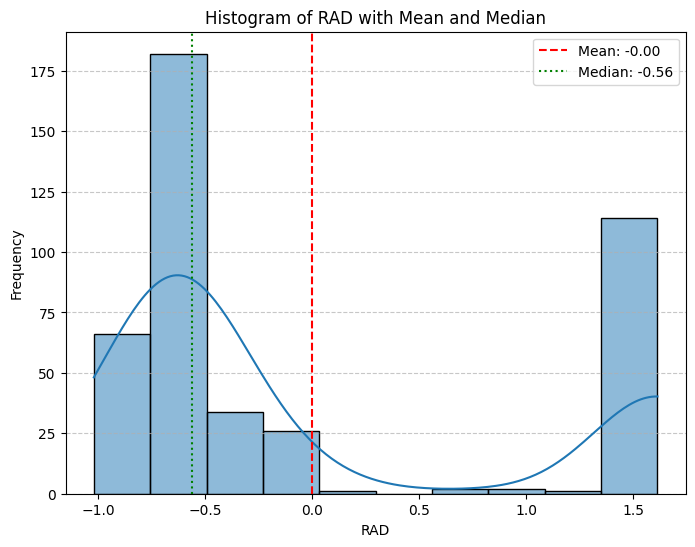

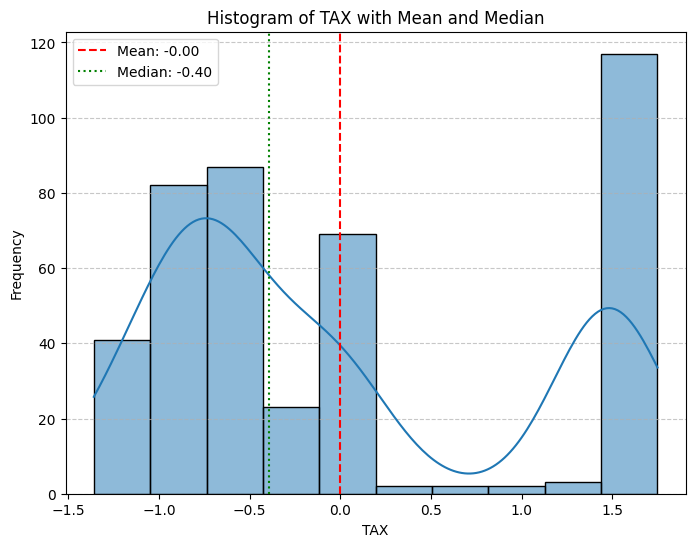

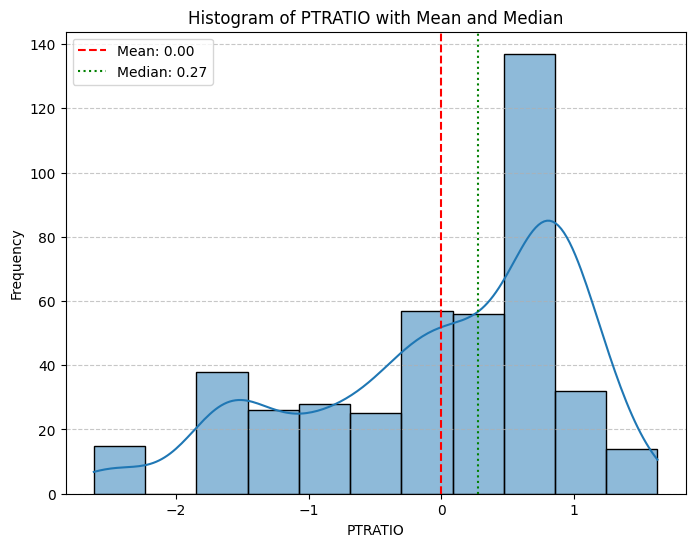

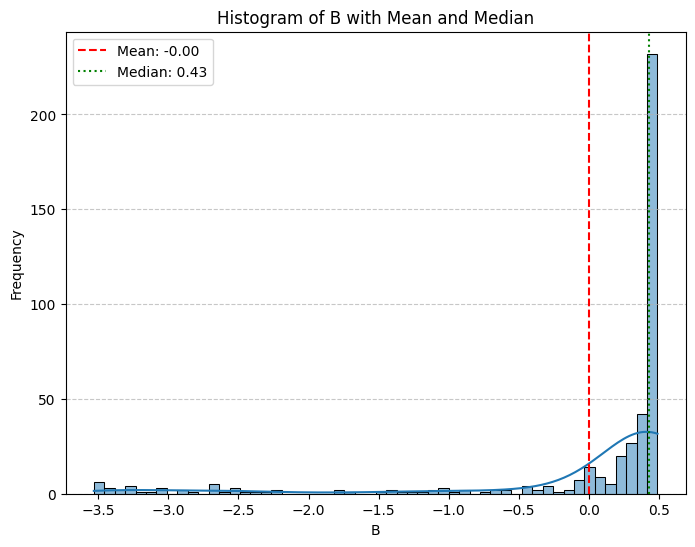

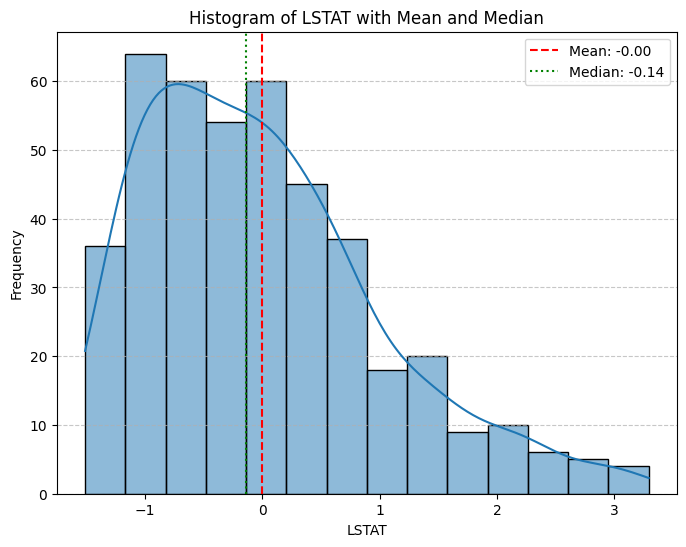

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all column names from the DataFrame
columns = X_train_scaled.columns.tolist()

# Generate a histogram for each column
for col in columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(X_train_scaled[col].dropna(), kde=True) # kde=True adds a Kernel Density Estimate; dropna to handle missing values

    # Calculate mean and median, dropping NaN values first
    mean_val = X_train_scaled[col].mean()
    median_val = X_train_scaled[col].median()

    # Add vertical line for the mean
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    # Add vertical line for the median
    plt.axvline(median_val, color='green', linestyle=':', label=f'Median: {median_val:.2f}')

    plt.title(f'Histogram of {col} with Mean and Median')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend() # Show the legend for mean and median lines
    plt.show()

### Entrenamiento y Evaluación del Modelo de Regresión Lineal
Ahora, utilizaremos el modelo de Regresión Lineal para predecir los valores de `MEDV` y evaluaremos su rendimiento.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Crear una instancia del modelo de Regresión Lineal
linear_model = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento escalados
linear_model.fit(X_train_scaled, y_train)

# Realizar predicciones en el conjunto de prueba escalado
y_pred = linear_model.predict(X_test_scaled)

# Evaluar el rendimiento del modelo
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Calcula la raíz cuadrada del MSE
r2 = r2_score(y_test, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

Error Absoluto Medio (MAE): 4.69
Error Cuadrático Medio (MSE): 57.52
Raíz del Error Cuadrático Medio (RMSE): 7.58
Coeficiente de Determinación (R²): 0.31


### Visualización de Predicciones vs. Valores Reales
Para entender mejor cómo el modelo realiza las predicciones, podemos visualizar los valores reales frente a los predichos en el conjunto de prueba.

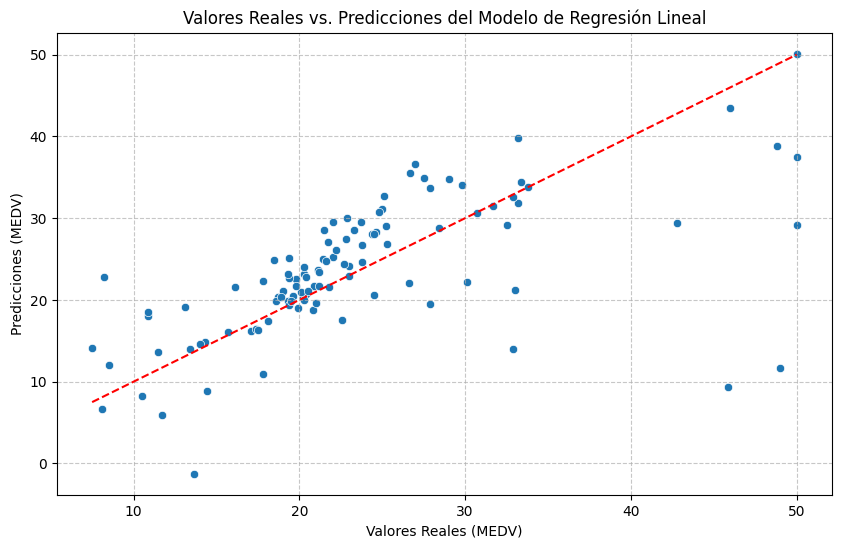

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Línea de referencia y=x
plt.xlabel('Valores Reales (MEDV)')
plt.ylabel('Predicciones (MEDV)')
plt.title('Valores Reales vs. Predicciones del Modelo de Regresión Lineal')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Comparación de Modelos de Regresión Lineal y Regularización

A continuación, entrenaremos y evaluaremos `LinearRegression`, `Ridge`, `Lasso` y `ElasticNet` para comparar su rendimiento en los conjuntos de entrenamiento y prueba. Los resultados se presentarán en un DataFrame para una fácil visualización.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Definir los modelos a evaluar
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42 ),
    "Lasso": Lasso(random_state=42),
    "ElasticNet": ElasticNet(random_state=42 )
}

results = []

# Iterar sobre cada modelo
for name, model in models.items():
    # Entrenar el modelo
    model.fit(X_train_scaled, y_train)

    # Realizar predicciones
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Calcular métricas de entrenamiento
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_train_pred)

    # Calcular métricas de prueba
    mae_test = mean_absolute_error(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_test_pred)

    # Guardar resultados
    results.append({
        'Model': name,
        'MAE (Train)': mae_train,
        'MAE (Test)': mae_test,
        'MSE (Train)': mse_train,
        'MSE (Test)': mse_test,
        'RMSE (Train)': rmse_train,
        'RMSE (Test)': rmse_test,
        'R2 (Train)': r2_train,
        'R2 (Test)': r2_test
    })

# Crear un DataFrame con los resultados
results_df = pd.DataFrame(results)

# Mostrar el DataFrame de resultados
display(results_df)

,Model,MAE (Train),MAE (Test),MSE (Train),MSE (Test),RMSE (Train),RMSE (Test),R2 (Train),R2 (Test)
0,Linear Regression,3.849499,4.689806,30.786684,57.881756,5.548575,7.608006,0.663405,0.304070
1,Ridge,3.845339,4.678260,30.787464,57.595424,5.548645,7.589165,0.663397,0.307512
2,Lasso,4.389366,4.130098,40.497967,42.347806,6.363801,6.507519,0.557230,0.490839
3,ElasticNet,4.374241,4.120519,40.544085,42.704818,6.367424,6.534892,0.556726,0.486547


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Definir los modelos a evaluar
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "ElasticNet": ElasticNet(random_state=42)
}

results = []

# Iterar sobre cada modelo
for name, model in models.items():
    # Entrenar el modelo
    model.fit(X_train_scaled, y_train)

    # Realizar predicciones
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Calcular métricas de entrenamiento
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_train_pred)

    # Calcular métricas de prueba
    mae_test = mean_absolute_error(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_test_pred)

    # Guardar resultados
    results.append({
        'Model': name,
        'MAE (Train)': mae_train,
        'MAE (Test)': mae_test,
        'MSE (Train)': mse_train,
        'MSE (Test)': mse_test,
        'RMSE (Train)': rmse_train,
        'RMSE (Test)': rmse_test,
        'R2 (Train)': r2_train,
        'R2 (Test)': r2_test
    })

# Crear un DataFrame con los resultados
results_df = pd.DataFrame(results)

# Mostrar el DataFrame de resultados
display(results_df)

,Model,MAE (Train),MAE (Test),MSE (Train),MSE (Test),RMSE (Train),RMSE (Test),R2 (Train),R2 (Test)
0,Linear Regression,3.838426,4.694256,30.345237,57.521488,5.508651,7.584292,0.668231,0.308401
1,Ridge,3.833538,4.680477,30.346166,57.244872,5.508735,7.566034,0.668221,0.311727
2,Lasso,4.388645,4.127343,40.348945,42.286492,6.352082,6.502806,0.558860,0.491576
3,ElasticNet,4.372317,4.110852,40.395484,42.676563,6.355744,6.532730,0.558351,0.486886


### Optimización de Hiperparámetros para Ridge Regression

Vamos a utilizar `GridSearchCV` para encontrar el valor óptimo del hiperparámetro `alpha` para el modelo de `Ridge Regression`. Este parámetro controla la fuerza de la penalización L2. Un `alpha` más grande significa una mayor penalización, lo que puede ayudar a reducir la complejidad del modelo y prevenir el sobreajuste.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# Definir el rango de valores de alpha a probar
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Crear una instancia de Ridge Regression
ridge = Ridge(random_state=42)

# Configurar GridSearchCV
grid_search_ridge = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid_ridge,
    scoring='neg_mean_squared_error', # Usamos neg_mean_squared_error para que GridSearchCV minimice el error
    cv=5, # 5-fold cross-validation
    n_jobs=-1, # Usar todos los núcleos disponibles
    verbose=1
)

# Ejecutar la búsqueda en cuadrícula
grid_search_ridge.fit(X_train_scaled, y_train)

# Obtener el mejor alpha y el mejor score
best_alpha_ridge = grid_search_ridge.best_params_['alpha']
best_rmse_ridge = np.sqrt(-grid_search_ridge.best_score_)

print(f"Mejor alpha para Ridge: {best_alpha_ridge}")
print(f"Mejor RMSE de validación cruzada para Ridge: {best_rmse_ridge:.2f}")

# Entrenar el modelo Ridge con el mejor alpha encontrado
best_ridge_model = Ridge(alpha=best_alpha_ridge, random_state=42)
best_ridge_model.fit(X_train_scaled, y_train)

# Realizar predicciones con el mejor modelo Ridge
y_train_pred_best_ridge = best_ridge_model.predict(X_train_scaled)
y_test_pred_best_ridge = best_ridge_model.predict(X_test_scaled)

# Evaluar el mejor modelo Ridge
mae_train_best_ridge = mean_absolute_error(y_train, y_train_pred_best_ridge)
mse_train_best_ridge = mean_squared_error(y_train, y_train_pred_best_ridge)
rmse_train_best_ridge = np.sqrt(mse_train_best_ridge)
r2_train_best_ridge = r2_score(y_train, y_train_pred_best_ridge)

mae_test_best_ridge = mean_absolute_error(y_test, y_test_pred_best_ridge)
mse_test_best_ridge = mean_squared_error(y_test, y_test_pred_best_ridge)
rmse_test_best_ridge = np.sqrt(mse_test_best_ridge)
r2_test_best_ridge = r2_score(y_test, y_test_pred_best_ridge)

print("\nEvaluación del Mejor Modelo Ridge (Entrenamiento):")
print(f"  Error Absoluto Medio (MAE): {mae_train_best_ridge:.2f}")
print(f"  Error Cuadrático Medio (MSE): {mse_train_best_ridge:.2f}")
print(f"  Raíz del Error Cuadrático Medio (RMSE): {rmse_train_best_ridge:.2f}")
print(f"  Coeficiente de Determinación (R²): {r2_train_best_ridge:.2f}")

print("\nEvaluación del Mejor Modelo Ridge (Prueba):")
print(f"  Error Absoluto Medio (MAE): {mae_test_best_ridge:.2f}")
print(f"  Error Cuadrático Medio (MSE): {mse_test_best_ridge:.2f}")
print(f"  Raíz del Error Cuadrático Medio (RMSE): {rmse_test_best_ridge:.2f}")
print(f"  Coeficiente de Determinación (R²): {r2_test_best_ridge:.2f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejor alpha para Ridge: 10
Mejor RMSE de validación cruzada para Ridge: 5.88

Evaluación del Mejor Modelo Ridge (Entrenamiento):
  Error Absoluto Medio (MAE): 3.80
  Error Cuadrático Medio (MSE): 30.42
  Raíz del Error Cuadrático Medio (RMSE): 5.52
  Coeficiente de Determinación (R²): 0.67

Evaluación del Mejor Modelo Ridge (Prueba):
  Error Absoluto Medio (MAE): 4.59
  Error Cuadrático Medio (MSE): 55.02
  Raíz del Error Cuadrático Medio (RMSE): 7.42
  Coeficiente de Determinación (R²): 0.34


### Optimización de Hiperparámetros para Lasso Regression

Ahora realizaremos una búsqueda similar para el hiperparámetro `alpha` del modelo de `Lasso Regression`. `Lasso` aplica una penalización L1, que además de regularizar, puede conducir a la selección de características al reducir algunos coeficientes a cero.

In [ ]:
from sklearn.linear_model import Lasso

# Definir el rango de valores de alpha a probar
param_grid_lasso = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}

# Crear una instancia de Lasso Regression
lasso = Lasso(random_state=42)

# Configurar GridSearchCV
grid_search_lasso = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid_lasso,
    scoring='neg_mean_squared_error', # Usamos neg_mean_squared_error
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Ejecutar la búsqueda en cuadrícula
grid_search_lasso.fit(X_train_scaled, y_train)

# Obtener el mejor alpha y el mejor score
best_alpha_lasso = grid_search_lasso.best_params_['alpha']
best_rmse_lasso = np.sqrt(-grid_search_lasso.best_score_)

print(f"Mejor alpha para Lasso: {best_alpha_lasso}")
print(f"Mejor RMSE de validación cruzada para Lasso: {best_rmse_lasso:.2f}")

# Entrenar el modelo Lasso con el mejor alpha encontrado
best_lasso_model = Lasso(alpha=best_alpha_lasso, random_state=42)
best_lasso_model.fit(X_train_scaled, y_train)

# Realizar predicciones con el mejor modelo Lasso
y_train_pred_best_lasso = best_lasso_model.predict(X_train_scaled)
y_test_pred_best_lasso = best_lasso_model.predict(X_test_scaled)

# Evaluar el mejor modelo Lasso
mae_train_best_lasso = mean_absolute_error(y_train, y_train_pred_best_lasso)
mse_train_best_lasso = mean_squared_error(y_train, y_train_pred_best_lasso)
rmse_train_best_lasso = np.sqrt(mse_train_best_lasso)
r2_train_best_lasso = r2_score(y_train, y_train_pred_best_lasso)

mae_test_best_lasso = mean_absolute_error(y_test, y_test_pred_best_lasso)
mse_test_best_lasso = mean_squared_error(y_test, y_test_pred_best_lasso)
rmse_test_best_lasso = np.sqrt(mse_test_best_lasso)
r2_test_best_lasso = r2_score(y_test, y_test_pred_best_lasso)

print("\nEvaluación del Mejor Modelo Lasso (Entrenamiento):")
print(f"  Error Absoluto Medio (MAE): {mae_train_best_lasso:.2f}")
print(f"  Error Cuadrático Medio (MSE): {mse_train_best_lasso:.2f}")
print(f"  Raíz del Error Cuadrático Medio (RMSE): {rmse_train_best_lasso:.2f}")
print(f"  Coeficiente de Determinación (R²): {r2_train_best_lasso:.2f}")

print("\nEvaluación del Mejor Modelo Lasso (Prueba):")
print(f"  Error Absoluto Medio (MAE): {mae_test_best_lasso:.2f}")
print(f"  Error Cuadrático Medio (MSE): {mse_test_best_lasso:.2f}")
print(f"  Raíz del Error Cuadrático Medio (RMSE): {rmse_test_best_lasso:.2f}")
print(f"  Coeficiente de Determinación (R²): {r2_test_best_lasso:.2f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejor alpha para Lasso: 0.01
Mejor RMSE de validación cruzada para Lasso: 5.89

Evaluación del Mejor Modelo Lasso (Entrenamiento):
  Error Absoluto Medio (MAE): 3.83
  Error Cuadrático Medio (MSE): 30.35
  Raíz del Error Cuadrático Medio (RMSE): 5.51
  Coeficiente de Determinación (R²): 0.67

Evaluación del Mejor Modelo Lasso (Prueba):
  Error Absoluto Medio (MAE): 4.68
  Error Cuadrático Medio (MSE): 57.25
  Raíz del Error Cuadrático Medio (RMSE): 7.57
  Coeficiente de Determinación (R²): 0.31
